In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import networkx as nx 
import graph_tool.all as gt 
import os
import sys
sys.path.append('/Users/glover.co/Documents/laszlo/NetDesign/scripts')
import assembly_tree as at
sys.path.append('/Users/glover.co/Documents/laszlo/NetDesign/scripts')
import mcmc

In [2]:
prot_num = 1300
mol_num = 196
ikea_num = 102 

In [16]:
files = os.listdir('../data/circuits/ltspice_demos/edgefiles')
Xfiles = os.listdir('../data/circuits/ltspice_demos/Xfiles')
graphs = []
Xs = []
for f in files:
    if f.endswith('.edge'):
        g = nx.read_edgelist(os.path.join('../data/circuits/ltspice_demos/edgefiles', f),nodetype=int)
        graphs.append(g)
        X = np.loadtxt(os.path.join('../data/circuits/ltspice_demos/Xfiles', 'X_' + f.replace('.edge', '.txt')))
        Xs.append(X)


In [17]:
num_edges = [g.number_of_edges() for g in graphs]

In [18]:
max(num_edges)

121

In [19]:
X = Xs[19]
g = graphs[19]
O = at.extract_O(g,X)
capacity = at.extract_deg_cap(g,X).reshape(-1)

In [20]:
initial_graph = nx.Graph()
initial_graph.add_nodes_from(g.nodes())
at.prob_dist(X,O,capacity,T = 1000,initial_graph = initial_graph,rewire_est=True,max_edges=True)
# res = at.find_optimal_edge_count(X,O,capacity,initial_graph)

start milp
True


(array([1, 1, 1, 1, 1, 1, 1, 1, 2]),
 array([8, 7, 6, 5, 4, 3, 2, 1, 0]),
 True)

In [11]:
res.x

array([1., 0., 0., ..., 0., 0., 0.])

In [15]:
at.microcanonical_ensemble(X,O,capacity,initial_graph=initial_graph,T=1000)

In [32]:
np.argmax(num_edges)*2
nodes = initial_graph.nodes()

In [34]:
deg = initial_graph.degree()
X[nodes,:]@capacity - np.array([deg[i] for i in nodes])

array([[2., 2., 2., ..., 2., 2., 2.],
       [5., 5., 5., ..., 5., 5., 5.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [2., 2., 2., ..., 2., 2., 2.],
       [1., 1., 1., ..., 1., 1., 1.]])

In [22]:
protein_sp = np.loadtxt('../data/proteins/specificity.txt')
molecule_sp = np.loadtxt('../data/molecules/specificity.txt')
robots_sp = np.loadtxt('../data/robots/specificity.txt')
circuit_sp = np.loadtxt('../data/circuits/specificity.txt')
ikea_sp = np.loadtxt('../data/IkeaData/specificity.txt')

In [51]:
prot_y, prot_x = np.histogram(protein_sp, bins=40, range=(0,1))
mol_y, mol_x = np.histogram(molecule_sp, bins=40, range=(0,1))
ikea_y, ikea_x = np.histogram(ikea_sp, bins=40, range=(0,1))
circuit_y, circuit_x = np.histogram(circuit_sp, bins=40, range=(0,1))
robot_y, robot_x = np.histogram(robots_sp, bins=40, range=(0,1))
prot_y = prot_y / np.sum(prot_y)
mol_y = mol_y / np.sum(mol_y)
ikea_y = ikea_y / np.sum(ikea_y)
circuit_y = circuit_y / np.sum(circuit_y)
robot_y = robot_y / np.sum(robot_y)


In [52]:
prot_x = (prot_x[:-1] + prot_x[1:]) / 2
mol_x = (mol_x[:-1] + mol_x[1:]) / 2
ikea_x = (ikea_x[:-1] + ikea_x[1:]) / 2
circuit_x = (circuit_x[:-1] + circuit_x[1:]) / 2
robot_x = (robot_x[:-1] + robot_x[1:]) / 2


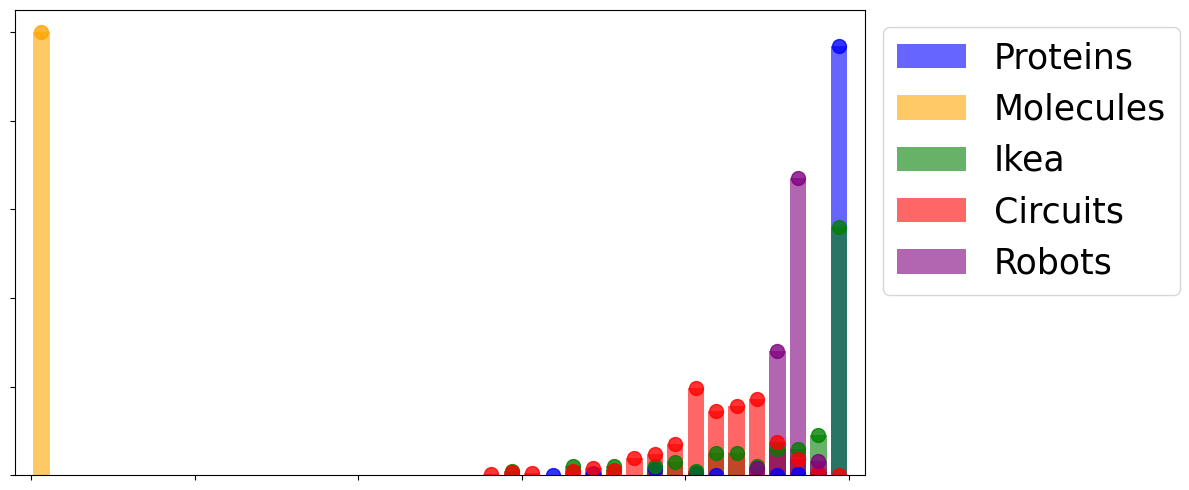

In [60]:
plt.figure(figsize=(12, 5))

# Filter and plot bars for Proteins
non_zero_prot = prot_y > 0
plt.bar(prot_x[non_zero_prot], prot_y[non_zero_prot], width=0.02, label='Proteins', color='blue', alpha=0.6)

# Filter and plot bars for Molecules
non_zero_mol = mol_y > 0
plt.bar(mol_x[non_zero_mol], mol_y[non_zero_mol], width=0.02, label='Molecules', color='orange', alpha=0.6)

# Filter and plot bars for Ikea
non_zero_ikea = ikea_y > 0
plt.bar(ikea_x[non_zero_ikea], ikea_y[non_zero_ikea], width=0.02, label='Ikea', color='green', alpha=0.6)

# Filter and plot bars for Circuits
non_zero_circuit = circuit_y > 0
plt.bar(circuit_x[non_zero_circuit], circuit_y[non_zero_circuit], width=0.02, label='Circuits', color='red', alpha=0.6)

# Filter and plot bars for Robots
non_zero_robot = robot_y > 0
plt.bar(robot_x[non_zero_robot], robot_y[non_zero_robot], width=0.02, label='Robots', color='purple', alpha=0.6)

# Add dots at the top of the bars
plt.scatter(prot_x[non_zero_prot], prot_y[non_zero_prot], color='blue', s=100, alpha=0.8)
plt.scatter(mol_x[non_zero_mol], mol_y[non_zero_mol], color='orange', s=100, alpha=0.8)
plt.scatter(ikea_x[non_zero_ikea], ikea_y[non_zero_ikea], color='green', s=100, alpha=0.8)
plt.scatter(circuit_x[non_zero_circuit], circuit_y[non_zero_circuit], color='red', s=100, alpha=0.8)
plt.scatter(robot_x[non_zero_robot], robot_y[non_zero_robot], color='purple', s=100, alpha=0.8)

plt.xticks(ticks=plt.xticks()[0], labels=[])
plt.yticks(ticks=plt.yticks()[0], labels=[])
plt.xlim(-.02, 1.02)
plt.ylim(0, 1.05)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=25)
plt.tight_layout()
plt.savefig('/Users/glover.co/CCNR Dropbox/Success Team/Glover, Cory/network_design/drafts/Network-Design-March-2025-/v10/figs/specificity_distributions.png', bbox_inches='tight', dpi=300)
plt.show()


In [61]:
ikea_sp[30]

np.float64(1.0)

In [72]:
np.min(protein_sp[protein_sp>0])

np.float64(0.625)

In [73]:
np.where(protein_sp == 0.625)

(array([316]),)

In [102]:
protein_sa = np.loadtxt('../data/proteins/sa.txt')
molecule_sa = np.loadtxt('../data/molecules/sa.txt')
robots_sa = np.loadtxt('../data/robots/sa.txt')
circuit_sa = np.loadtxt('../data/circuits/sa.txt')
ikea_sa = np.loadtxt('../data/IkeaData/sa.txt')

In [103]:
prot_max_div = np.loadtxt('../data/proteins/max_diversity.txt')
mol_max_div = np.loadtxt('../data/molecules/max_diversity.txt')
robots_max_div = np.loadtxt('../data/robots/max_diversity.txt')
circuit_max_div = np.loadtxt('../data/circuits/max_diversity.txt')
ikea_max_div = np.loadtxt('../data/IkeaData/max_diversity.txt')
prot_max_div_perc = prot_max_div.sum() / protein_sa[protein_sa > 0].sum()
mol_max_div_perc = mol_max_div.sum() / molecule_sa[molecule_sa > 0].sum()
robots_max_div_perc = robots_max_div.sum() / robots_sa[robots_sa > 0].sum()
circuit_max_div_perc = circuit_max_div.sum() / circuit_sa[circuit_sa > 0].sum()
ikea_max_div_perc = ikea_max_div.sum() / ikea_sa[ikea_sa > 0].sum()

/var/folders/8t/4z1vq2xd5790h0y5jrvphttr0000gp/T/ipykernel_14570/3005731854.py:8: RuntimeWarning: divide by zero encountered in scalar divide
  robots_max_div_perc = robots_max_div.sum() / robots_sa[robots_sa > 0].sum()


In [104]:
prot_sa_y, prot_sa_x = np.histogram(protein_sa, bins=2, range=(0,1))
mol_sa_y, mol_sa_x = np.histogram(molecule_sa, bins=2, range=(0,1))
ikea_sa_y, ikea_sa_x = np.histogram(ikea_sa, bins=2, range=(0,1))
circuit_sa_y, circuit_sa_x = np.histogram(circuit_sa, bins=2, range=(0,1))
robot_sa_y, robot_sa_x = np.histogram(robots_sa, bins=2, range=(0,1))
prot_sa_y = prot_sa_y / np.sum(prot_sa_y)
mol_sa_y = mol_sa_y / np.sum(mol_sa_y)
ikea_sa_y = ikea_sa_y / np.sum(ikea_sa_y)
circuit_sa_y = circuit_sa_y / np.sum(circuit_sa_y)
robot_sa_y = robot_sa_y / np.sum(robot_sa_y)

In [105]:
prot_sa_x = (prot_sa_x[:-1] + prot_sa_x[1:]) / 2
mol_sa_x = (mol_sa_x[:-1] + mol_sa_x[1:]) / 2
ikea_sa_x = (ikea_sa_x[:-1] + ikea_sa_x[1:]) / 2
circuit_sa_x = (circuit_sa_x[:-1] + circuit_sa_x[1:]) / 2
robot_sa_x = (robot_sa_x[:-1] + robot_sa_x[1:]) / 2

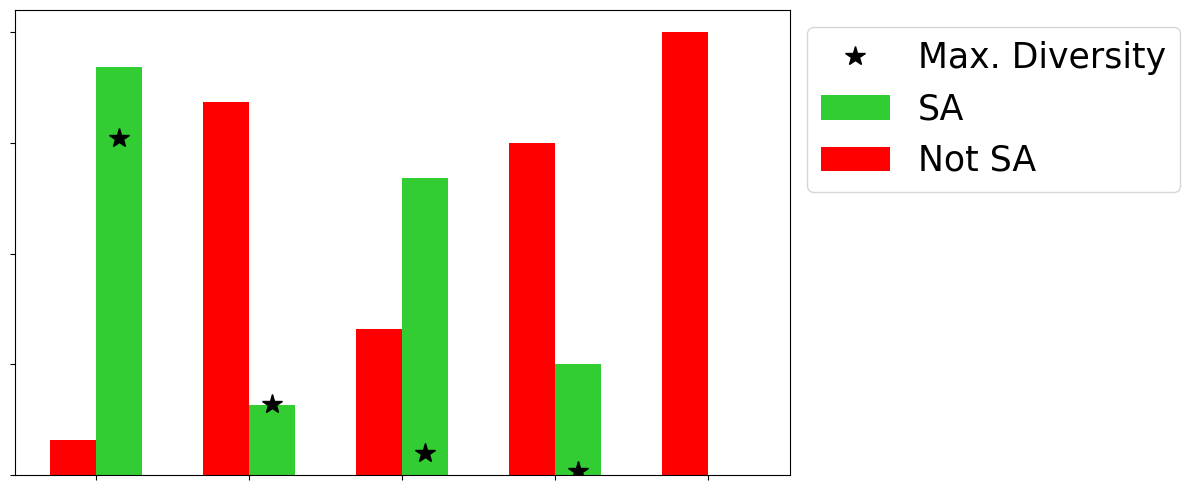

In [118]:
plt.figure(figsize=(12, 5))
# Make bar plots for each dataset side by side
plt.bar(.3, prot_sa_y[1], width=0.3, color='#32CD32', label='SA', alpha=1)
plt.bar(0, prot_sa_y[0], width=0.3, label='Not SA', color='red', alpha=1)
plt.bar(1, mol_sa_y[0], width=0.3, color='red', alpha=1)
plt.bar(1.3, mol_sa_y[1], width=0.3, color='#32CD32', alpha=1)
plt.bar(2, ikea_sa_y[0], width=0.3, color='red', alpha=1)
plt.bar(2.3, ikea_sa_y[1], width=0.3, color='#32CD32', alpha=1)
plt.bar(3, circuit_sa_y[0], width=0.3, color='red', alpha=1)
plt.bar(3.3, circuit_sa_y[1], width=0.3, color='#32CD32', alpha=1)
plt.bar(4, robot_sa_y[0], width=0.3, color='red', alpha=1)
plt.bar(4.3, robot_sa_y[1], width=0.3, color='#32CD32', alpha=1)
plt.plot(.3, prot_max_div_perc, '*', color='black', markersize=15, label='Max. Diversity') 
plt.plot(1.3, mol_max_div_perc, '*', color='black', markersize=15)
plt.plot(2.3, ikea_max_div_perc, '*', color='black', markersize=15)
plt.plot(3.3, circuit_max_div_perc, '*', color='black', markersize=15)
plt.plot(4.3, robots_max_div_perc, '*', color='black', markersize=15)
plt.xticks([0.15, 1.15, 2.15, 3.15, 4.15], ['', '', '', '', ''])
plt.yticks(ticks=[0,.25,.5,.75,1.0], labels=[])
# plt.ylabel('Percentage of Self-Assembly')
plt.legend(loc='upper left',bbox_to_anchor=(1, 1),fontsize=25)
plt.tight_layout()
plt.savefig('/Users/glover.co/CCNR Dropbox/Success Team/Glover, Cory/network_design/drafts/Network-Design-March-2025-/v10/figs/self_assembly.pdf', bbox_inches='tight', dpi=300)


In [ ]:
prot_max_div = np.loadtxt('../data/proteins/max_diversity.txt')
mol_max_div = np.loadtxt('../data/molecules/max_diversity.txt')
robots_max_div = np.loadtxt('../data/robots/max_diversity.txt')
circuit_max_div = np.loadtxt('../data/circuits/max_diversity.txt')
ikea_max_div = np.loadtxt('../data/IkeaData/max_diversity.txt')
prot_max_div_perc = prot_max_div.sum() / 

In [101]:
prot_max_div.sum()

np.float64(851.0)